Create Figure S8

In [1]:
#load packages needed in this notebook
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os
from eofs.standard import Eof
import regionmask
import cartopy.crs as ccrs
from matplotlib import pyplot as PP
import copy
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/home/nmaher/.conda/envs/clara/share/proj failed


In [2]:
#define models and start years

models=['CESM2','CESM1-LE','ACCESS-SSP370','CanESM5-SSP370','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']
models_title=['CESM2','CESM1','ACCESS','CanESM5','GFDL-SPEAR','IPSL-CM6A','MIROC6','MPI-GE']

#tell me when the start year is 
syear=[1850,1920,1850,1850,1921,1850,1850,1850]
#offset=1920-syear

#load lon lat should be same for all models
outputdira='/glade/campaign/cgd/cas/nmaher/cesm1_lens/Amon/zg/' 
ds_fx = xr.open_dataset(outputdira+'zg_Amon_CESM1-CAM5_historical_rcp85_r10i1p1_192001-210012_g025.nc')

lon = ds_fx.lon
lat = ds_fx.lat

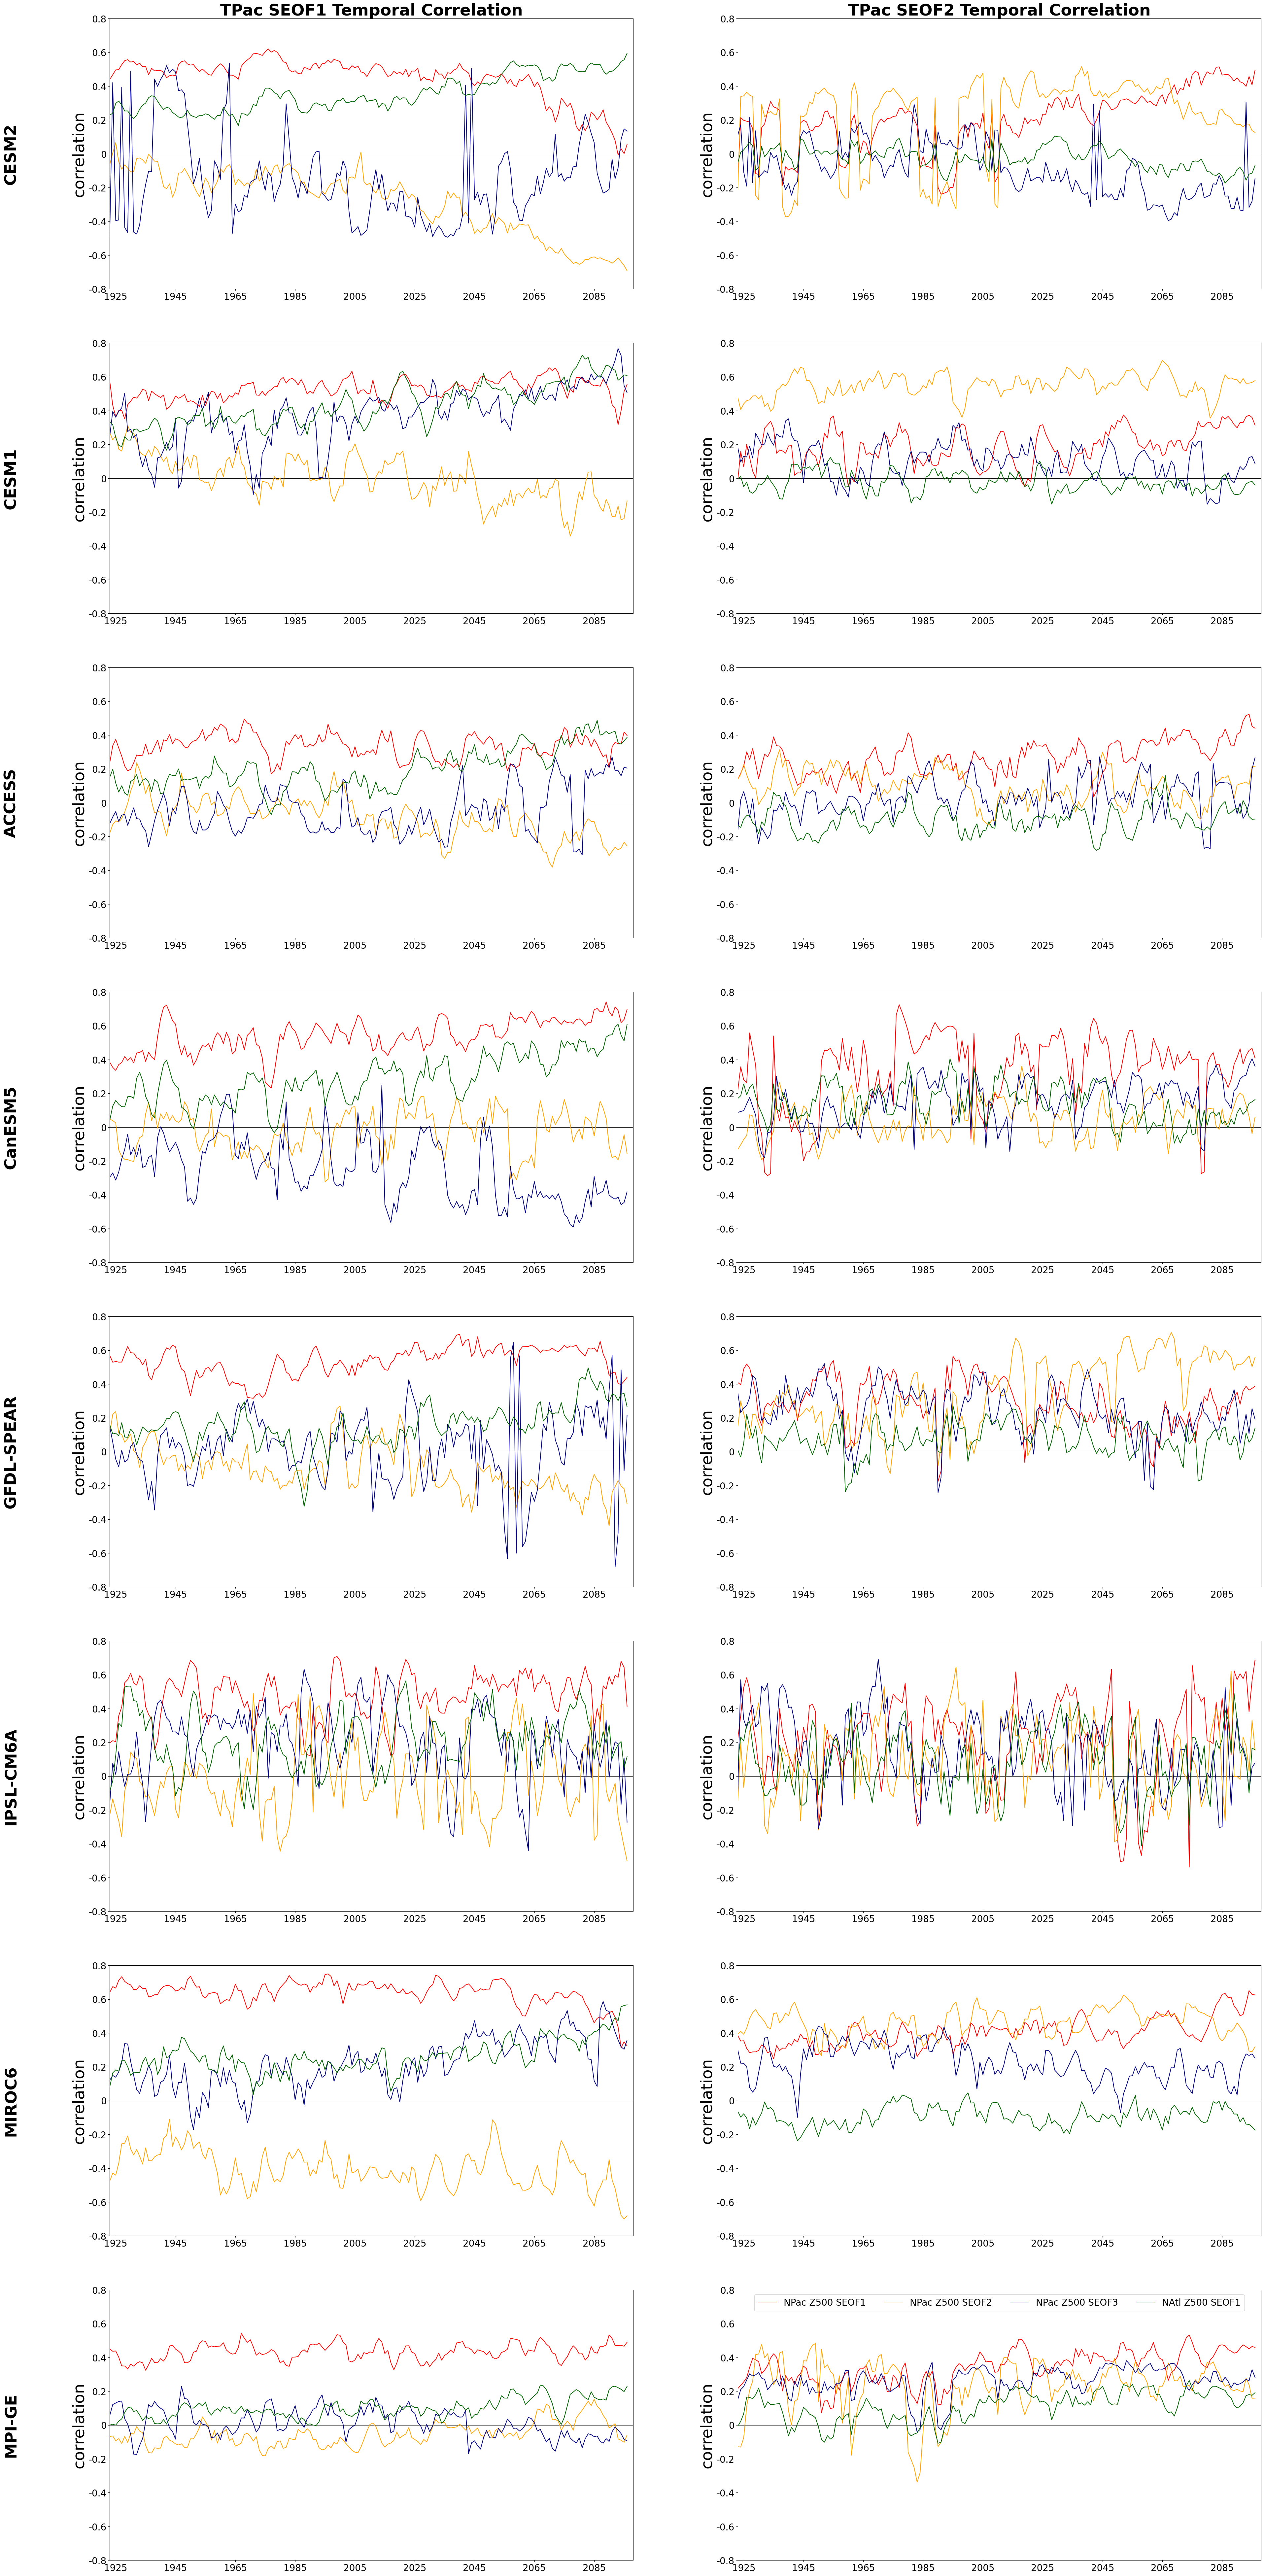

In [3]:
from scipy.optimize import curve_fit


#save output
outputdir2='/glade/work/nmaher/SEOF_output/'
outputdir2b='/glade/work/nmaher/SEOF_output/Fig_data/'

from matplotlib.gridspec import GridSpec

fig,axs = PP.subplots(8,2,figsize=(45,100))
#fig,axs= plt.figure(figsize=(45,100))
#gs=GridSpec(8,2, wspace=0.3)


ii=-1
for model in models:
    ii=ii+1
    offset=1921-syear[ii]

    
    
    with np.load(outputdir2b+model+'_SPCs_zgNPac.npz') as npz:
        npac_spcs = np.ma.MaskedArray(**npz)
    
    with np.load(outputdir2b+model+'_SPCs_zgNAt.npz') as npz:
        nat_spcs = np.ma.MaskedArray(**npz)

    with np.load(outputdir2b+model+'_SPCs_zgTPac.npz') as npz:
        tpac_spcs = np.ma.MaskedArray(**npz)



    enso_eof_correlations = np.ma.masked_equal(np.zeros([2,4,176]),0)

    eof_dates = np.array([1923+i for i in range(176)])
    panel_labels = ['(a)','(b)']

    def lin_model(x, a, b):
        return a * x + b

    colors = ['red','orange','navy','darkgreen']
    leg_labs = ['NPac Z500 SEOF1','NPac Z500 SEOF2','NPac Z500 SEOF3','NAtl Z500 SEOF1']

    noms = []

    for k in range(2):

        for j in range(4):

            for i in range(174)[:]:
                if j <3:
                    corrcoef = np.corrcoef(tpac_spcs[i+offset,:,k],npac_spcs[i+offset,:,j])[0,1]
                else:
                    corrcoef = np.corrcoef(tpac_spcs[i+offset,:,k],nat_spcs[i+offset,:,j-3])[0,1]
                    
            #print(corrcoef)
                enso_eof_correlations[k,j,i] = corrcoef
       

            axs[ii,k].axhline(y=0,c='k',linewidth=0.5,zorder=0)
       
            axs[ii,k].plot(eof_dates,enso_eof_correlations[k,j,:], color=colors[j], label=leg_labs[j])
            
            axs[ii,k].set_ylabel('correlation',fontsize=35)
            
            xticks = np.arange(1925,2100,5)[::4]
            axs[ii,k].set_xticks(xticks,fontsize=20)
            axs[ii,k].set_xticklabels(xticks,fontsize=20)

            yticks = [-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8]
            axs[ii,k].set_yticks(yticks,fontsize=20)
            axs[ii,k].set_yticklabels(yticks,fontsize=20)

    axs[ii,0].set_ylim([-0.8,0.8])
    axs[ii,1].set_ylim([-0.8,0.8])

    axs[ii,0].set_xlim([1923,2098])
    axs[ii,1].set_xlim([1923,2098])
    axs[ii,0].text(1890,0,models_title[ii], rotation=90, fontsize=35, ha='center', va='center', weight='bold')   

axs[0,0].set_title('TPac SEOF1 Temporal Correlation', fontsize=35, weight='bold')

axs[0,1].set_title('TPac SEOF2 Temporal Correlation', fontsize=35, weight='bold')
PP.legend(loc='upper center',ncol=4, fontsize=20)

outputdir2='/glade/work/nmaher/SEOF_output/figs_final/revision/'



PP.savefig(outputdir2+'FigureS8.png')
PP.show()
